### Decision Trees and Random Forest Vignette

#### Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as skm

from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)

from sklearn.metrics import (accuracy_score, log_loss)

from sklearn.ensemble import \
    (RandomForestRegressor as RF,
     RandomForestClassifier as RFC)

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from matplotlib.pyplot import subplots
from ISLP import load_data
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                             classification_report, confusion_matrix)

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score


okabe_ito = {
    "orange":    "#E69F00",
    "sky_blue":  "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermilion": "#D55E00",
    "pink":      "#CC79A7",
    "black":     "#000000",
}

oi_colors = list(okabe_ito.values())

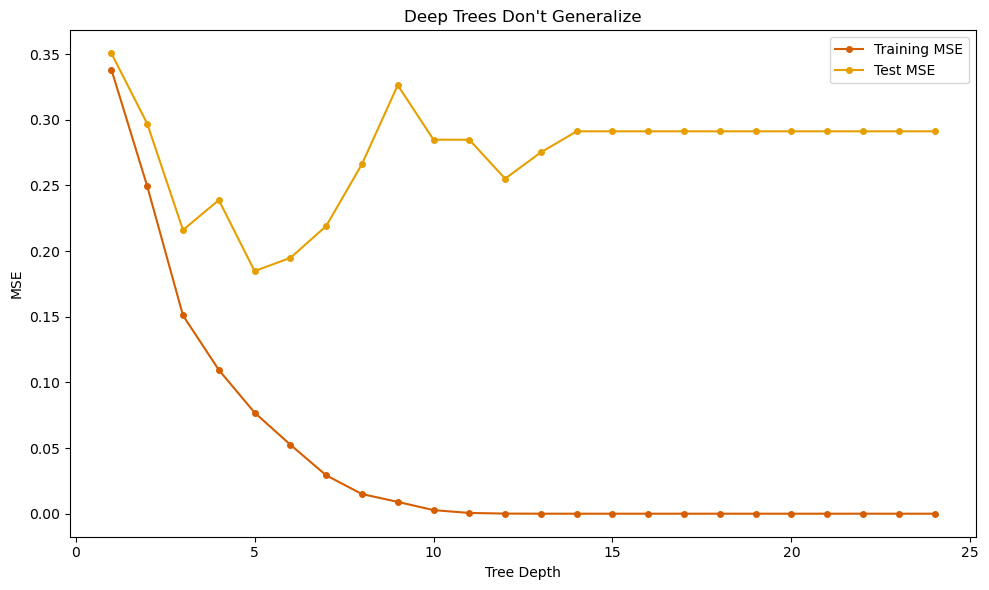

In [ ]:
# Load our data and get rid of points without the target
Hitters = load_data("Hitters").dropna(subset=["Salary"])

X_df = Hitters.drop(columns=["Salary"])

# Best to use log transform here

y_hitters = np.log(Hitters["Salary"].values)

# Train test split

(X_train,
X_test,
y_train,
y_test) = skm.train_test_split(X_df, y_hitters, test_size=0.3, random_state=0)

# The categorical cols are just which league, division, and if the player switched leagues

cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_df.select_dtypes(include=["number"]).columns.tolist()

# One-hot the categoricals, we don't need the standard scaler because
# the features get treated independently

ct = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols),
])


# We will transform everything now

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Get our feature names for plotting

feature_names = ct.get_feature_names_out().tolist()


# We will see how tree depth relates to accuracy in and out of sample
# Here the depths the longest path down the tree, so 25 is highly branched
# We could also limit max_leaf_nodes or min_samples_leaf

depths = range(1, 25)
train_mse = []
test_mse = []

for d in depths:

    # Create and fit our tree

    tree = DTR(max_depth=d, random_state=0)
    tree.fit(X_train, y_train)
    
    # Find the error
    
    train_mse.append(np.mean((y_train - tree.predict(X_train)) ** 2))
    test_mse.append(np.mean((y_test - tree.predict(X_test)) ** 2))

# Plot the training and testing error

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_mse, "-o",color=okabe_ito["vermilion"], markersize=4, label="Training MSE")
ax.plot(depths, test_mse, "-o",color=okabe_ito["orange"], markersize=4, label="Test MSE")
ax.set_xlabel("Tree Depth")
ax.set_ylabel("MSE")
ax.set_title("Deep Trees Don't Generalize")
ax.legend()
plt.tight_layout()
plt.show()

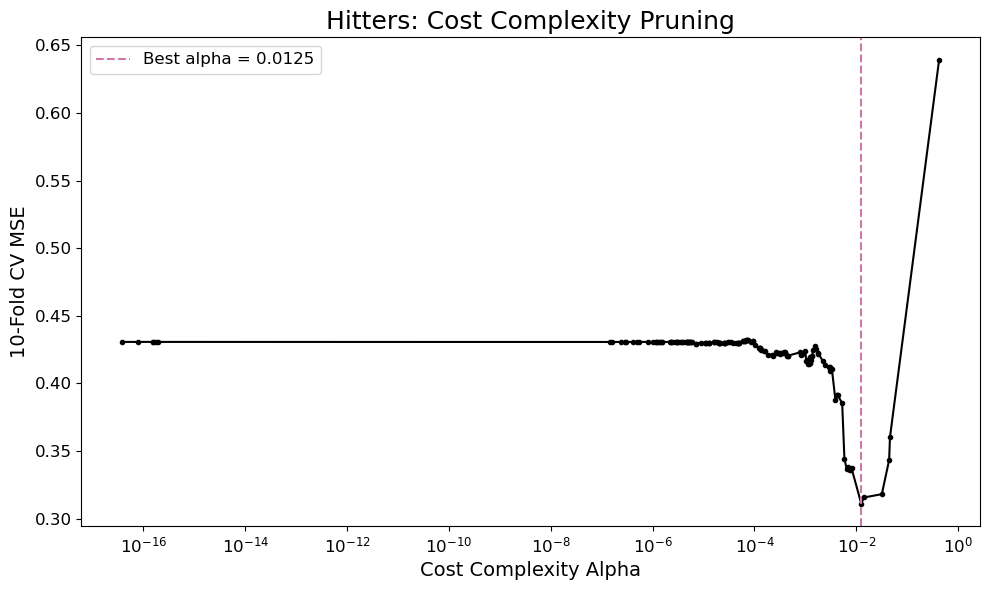

In [56]:
# Here we will do some pruning

# First you fit a full tree, the defaults let you go very deep

reg = DTR(random_state=0)
reg.fit(X_train, y_train)

# Now we prune, ccp_path will ratched up alpha from 0, recording the places at which pruning happens
# as well as the pruned sub-tree

ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
alphas = ccp_path.ccp_alphas

# I put these extra alphas in so that we can see the tree get shrunk all the way to null

#extra_alphas = np.logspace(
#    np.log10(alphas[alphas > 0].max()),
#    np.log10(alphas[alphas > 0].max()) + 2,
#    50
#)
#alphas_extended = np.concatenate([alphas, extra_alphas])
alphas_extended = alphas
# CV to find best alpha
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=10)

# Setup our grid

grid = skm.GridSearchCV(
    DTR(random_state=0), # Model to fit
    {"ccp_alpha": alphas_extended}, # regularization parameter
    refit=True, cv=kfold, # cv scheme, refit calculates a tree at the end on entire set
    scoring="neg_mean_squared_error" 
)

# The expensive step where we do the cross validation

G = grid.fit(X_train, y_train)

# Plot CV MSE vs alpha 
cv_mses = -G.cv_results_["mean_test_score"]
mask = alphas_extended > 0 # This is because alpha = 0 is undefined on the log scale


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alphas_extended[mask], cv_mses[mask], "-o", color="k", markersize=3)
ax.axvline(G.best_params_["ccp_alpha"], color=okabe_ito["pink"], linestyle="--",
           label=f"Best alpha = {G.best_params_['ccp_alpha']:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Cost Complexity Alpha", fontsize=14)
ax.set_ylabel("10-Fold CV MSE", fontsize=14)
ax.set_title("Hitters: Cost Complexity Pruning", fontsize=18)
ax.legend(fontsize=12)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

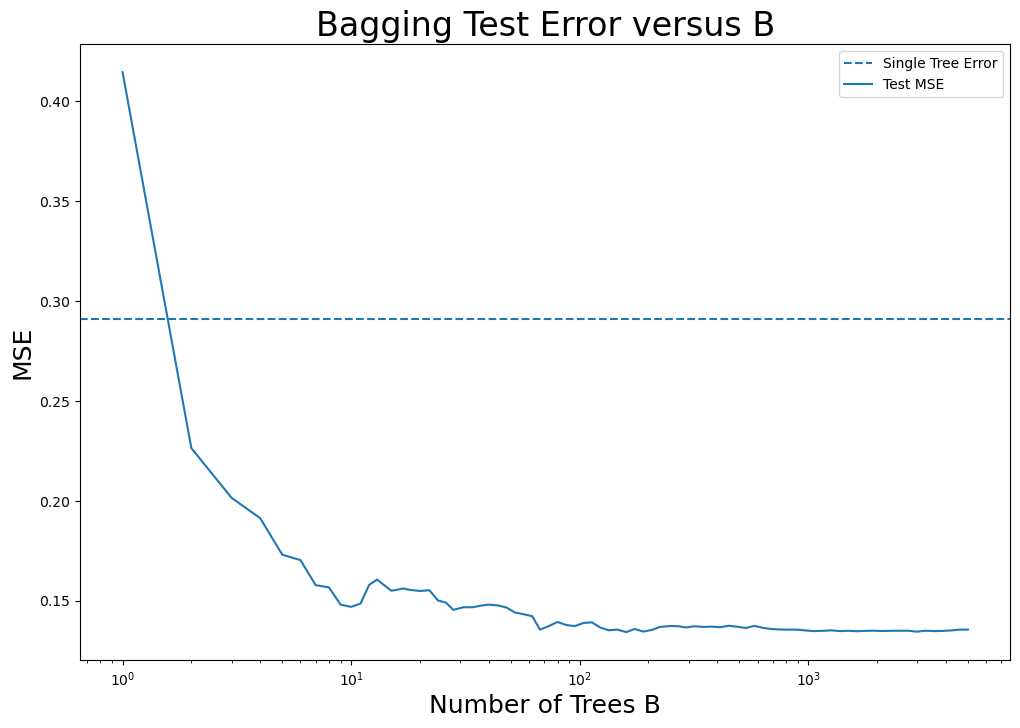

In [ ]:
# Want to show an exponential spacing so we can see that the error levels off

bag_vec = np.unique(np.logspace(0, np.log10(5000), 100).astype(int))

train_mse_vec = []
test_mse_vec = []

# We get the pruned single tree that was best from our cross-validation for comparison purposes

single_tree = G.best_estimator_
single_tree_mse = np.mean((y_test - single_tree.predict(X_test)) ** 2)

for j, bag_n in enumerate(bag_vec):

    bag_hitters = RF(max_features=X_train.shape[1], n_estimators = bag_n,random_state=0)
    bag_hitters.fit(X_train,y_train)

    y_hat_bag_train = bag_hitters.predict(X_train)
    train_mse_vec.append(np.mean((y_train-y_hat_bag_train)**2))

    y_hat_bag = bag_hitters.predict(X_test)
    test_mse_vec.append(np.mean((y_test-y_hat_bag)**2))


fig, ax = plt.subplots(figsize = (12,8))
ax.axhline(single_tree_mse, linestyle="--",
           label=f"Single Tree Error")

ax.plot(bag_vec,test_mse_vec,label="Test MSE")
ax.legend()
ax.set_title("Bagging Test Error versus B",fontsize=24)
ax.set_xscale("log")
ax.set_xlabel("Number of Trees B", fontsize=18)
ax.set_ylabel("MSE", fontsize=18);

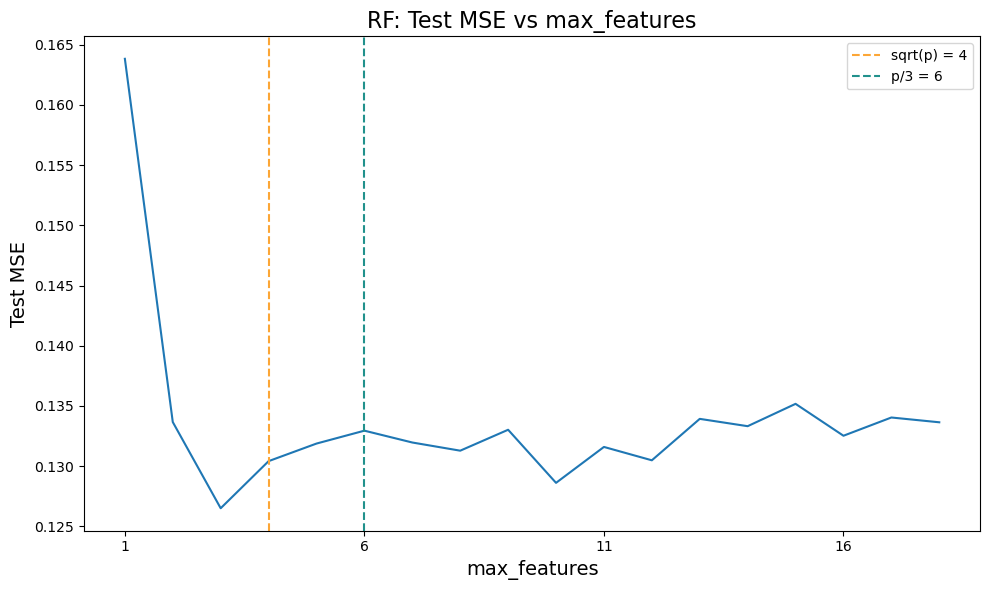

In [ ]:
bag_n = 500
fig, ax = plt.subplots(figsize=(10, 6))

p = X_train.shape[1]

test_mses = []

for max_features in np.arange(1, p):
    rf = RF(max_features=max_features, n_estimators=bag_n, random_state=1)
    rf.fit(X_train, y_train)
    test_mses.append(np.mean((y_test - rf.predict(X_test))**2))

ax.plot(np.arange(1, p), test_mses)

ax.axvline(int(np.sqrt(p)), color=okabe_ito["orange"], linestyle="--",
           label=f"sqrt(p) = {int(np.sqrt(p))}")
ax.axvline(int(p / 3), color=okabe_ito["green"], linestyle="--",
           label=f"p/3 = {int(p / 3)}")

ax.set_xlabel("max_features", fontsize=14)
ax.set_ylabel("Test MSE", fontsize=14)
ax.set_title("RF: Test MSE vs max_features", fontsize=16)
ax.set_xticks(np.arange(1, p,5))
ax.legend()
plt.tight_layout()
plt.show()

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/george

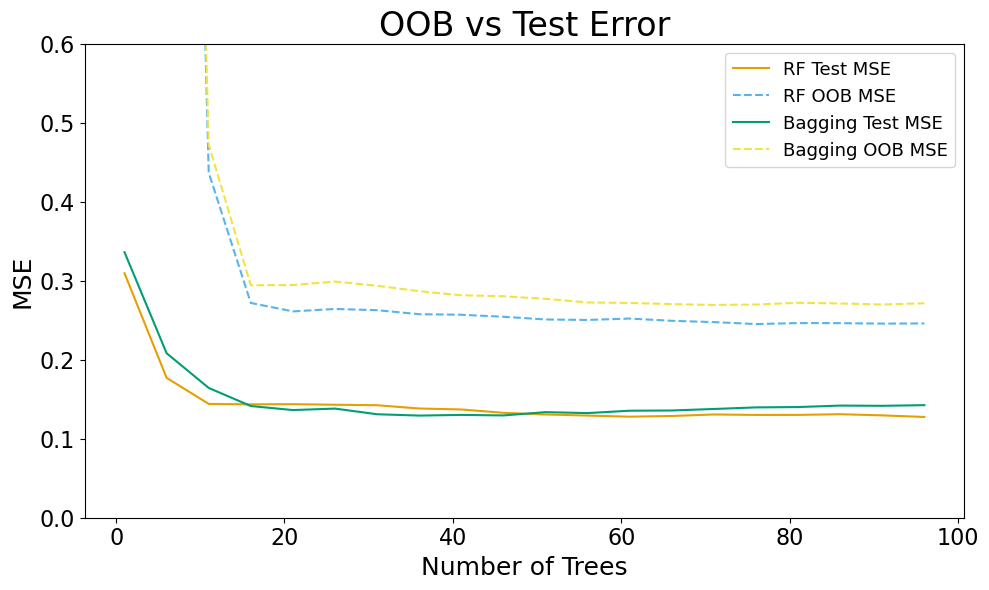

In [22]:
p = X_train.shape[1]
n_trees_vec = np.arange(1, 100, 5)



rf_oob = []
rf_test = []
bag_oob = []
bag_test = []

for n in n_trees_vec:

    rf = RF(max_features=3, n_estimators=n, oob_score=True, random_state=1)
    rf.fit(X_train, y_train)
    rf_oob.append(np.mean((y_train - rf.oob_prediction_) ** 2))
    rf_test.append(np.mean((y_test - rf.predict(X_test)) ** 2))

    bag = RF(max_features=p, n_estimators=n, oob_score=True, random_state=1)
    bag.fit(X_train, y_train)
    bag_oob.append(np.mean((y_train - bag.oob_prediction_) ** 2))
    bag_test.append(np.mean((y_test - bag.predict(X_test)) ** 2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_trees_vec, rf_test, "-", color=oi_colors[0], label="RF Test MSE")
ax.plot(n_trees_vec, rf_oob, "--", color=oi_colors[1], label="RF OOB MSE")
ax.plot(n_trees_vec, bag_test, "-", color=oi_colors[2], label="Bagging Test MSE")
ax.plot(n_trees_vec, bag_oob, "--", color=oi_colors[3], label="Bagging OOB MSE")

ax.set_ylim(0.0,0.6)

ax.set_xlabel("Number of Trees", fontsize=18)
ax.set_ylabel("MSE", fontsize=18)
ax.set_title("OOB vs Test Error", fontsize=24)
ax.legend(fontsize=13)
ax.tick_params(axis="both", labelsize=16)
plt.tight_layout()
plt.show()

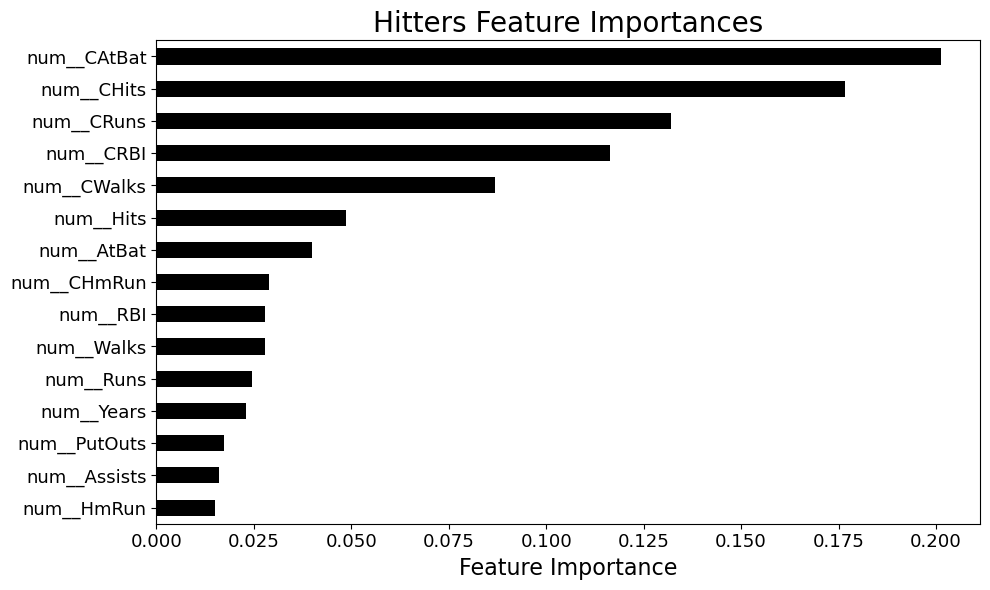

In [25]:
RF_Hitters = RF(max_features=int(p/3), n_estimators=500, random_state=1)
RF_Hitters.fit(X_train, y_train)

feature_imp = pd.DataFrame(
    {'importance': RF_Hitters.feature_importances_},
    index=feature_names
).sort_values(by='importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feature_imp.head(15).plot.barh(ax=ax, legend=False, color=okabe_ito["black"])
ax.invert_yaxis()
ax.set_xlabel("Feature Importance", fontsize=16)
ax.set_title("Hitters Feature Importances", fontsize=20)
ax.tick_params(axis="both", labelsize=13)
plt.tight_layout()
plt.show()

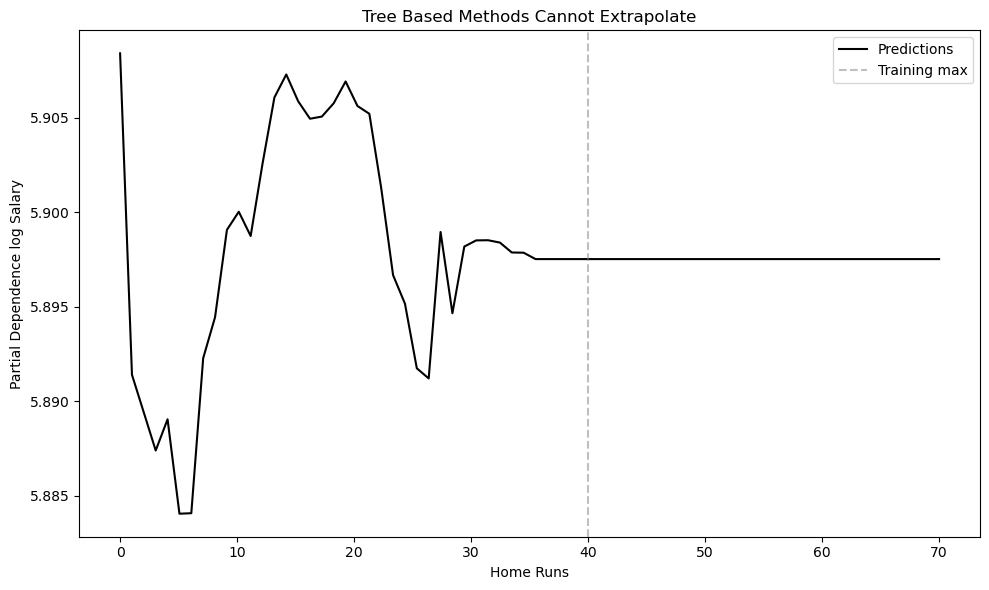

In [36]:
HMRun_idx = feature_names.index("num__HmRun")
grid_values = np.linspace(0, 70, 70)

fig, ax = plt.subplots(figsize=(10, 6))

pdp_values = []
for val in grid_values:
    X_temp = X_train.copy()
    X_temp[:, HMRun_idx] = val
    pdp_values.append(RF_Hitters.predict(X_temp).mean())

ax.plot(grid_values, pdp_values, color="k", label="Predictions")

ax.axvline(X_train[:, HMRun_idx].max(), color="gray", linestyle="--",
           alpha=0.5, label=f"Training max")

ax.set_xlabel("Home Runs")
ax.set_ylabel("Partial Dependence log Salary")
ax.set_title("Tree Based Methods Cannot Extrapolate")
ax.legend()
plt.tight_layout()
plt.show()